In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
apps = pd.read_csv("googleplaystore.csv")

In [4]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

In [6]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [7]:
apps.shape

(10841, 13)

In [8]:
reviews.shape

(64295, 5)

In [10]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [11]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


In [12]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [13]:
reviews.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [14]:
reviews.shape

(64295, 5)

In [15]:
reviews.duplicated().sum()

np.int64(33616)

In [16]:
apps_clean = apps.copy()
reviews_clean = reviews.copy()

In [17]:
apps_clean['App'].duplicated().sum()

np.int64(1181)

In [18]:
apps_clean = apps_clean.drop_duplicates(subset='App', keep='first')

In [19]:
apps_clean.shape

(9660, 13)

In [20]:
apps_clean['Reviews'] = pd.to_numeric(apps_clean['Reviews'], errors='coerce')

In [21]:
apps_clean['Reviews'].dtype

dtype('float64')

In [22]:
apps_clean['Installs'] = (
    apps_clean['Installs']
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
)

apps_clean['Installs'] = pd.to_numeric(
    apps_clean['Installs'],
    errors='coerce'
)

In [23]:
apps_clean['Installs'].head()

0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
Name: Installs, dtype: float64

In [24]:
apps_clean['Price'] = (
    apps_clean['Price']
    .str.replace('$', '', regex=False)
)

apps_clean['Price'] = pd.to_numeric(
    apps_clean['Price'],
    errors='coerce'
)

In [25]:
apps_clean['Price'].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64

In [26]:
def convert_size(size):
    if pd.isna(size):
        return np.nan
    
    size = str(size)
    
    if size == 'Varies with device':
        return np.nan
    
    if size.endswith('M'):
        return float(size.replace('M', ''))
    
    if size.endswith('k'):
        return float(size.replace('k', '')) / 1024
    
    return np.nan

apps_clean['Size_MB'] = apps_clean['Size'].apply(convert_size)

In [27]:
apps_clean[['Size', 'Size_MB']].head(10)

,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


In [28]:
apps_clean['Last Updated'] = pd.to_datetime(
    apps_clean['Last Updated'],
    errors='coerce'
)

In [29]:
apps_clean['Last Updated'].dtype

dtype('<M8[us]')

In [30]:
apps_clean.isnull().sum()

App                  0
Category             0
Rating            1463
Reviews              1
Size                 0
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         1
Current Ver          8
Android Ver          3
Size_MB           1228
dtype: int64

In [31]:
apps_clean['Rating'] = apps_clean.groupby('Category')['Rating'].transform(
    lambda x: x.fillna(x.median())
)

In [32]:
apps_clean['Rating'].isnull().sum()

np.int64(0)

In [33]:
apps_clean['Rating'] = apps_clean['Rating'].fillna(
    apps_clean['Rating'].median()
)

In [34]:
apps_clean['Type'] = apps_clean['Type'].fillna(
    apps_clean['Type'].mode()[0]
)

apps_clean['Content Rating'] = apps_clean['Content Rating'].fillna(
    apps_clean['Content Rating'].mode()[0]
)

In [35]:
apps_clean['Current Ver'] = apps_clean['Current Ver'].fillna('Unknown')
apps_clean['Android Ver'] = apps_clean['Android Ver'].fillna('Unknown')

In [36]:
apps_clean.isnull().sum()

App                  0
Category             0
Rating               0
Reviews              1
Size                 0
Installs             1
Type                 0
Price                1
Content Rating       0
Genres               0
Last Updated         1
Current Ver          0
Android Ver          0
Size_MB           1228
dtype: int64

In [37]:
apps_clean.info()

<class 'pandas.DataFrame'>
Index: 9660 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9660 non-null   str           
 1   Category        9660 non-null   str           
 2   Rating          9660 non-null   float64       
 3   Reviews         9659 non-null   float64       
 4   Size            9660 non-null   str           
 5   Installs        9659 non-null   float64       
 6   Type            9660 non-null   str           
 7   Price           9659 non-null   float64       
 8   Content Rating  9660 non-null   str           
 9   Genres          9660 non-null   str           
 10  Last Updated    9659 non-null   datetime64[us]
 11  Current Ver     9660 non-null   str           
 12  Android Ver     9660 non-null   str           
 13  Size_MB         8432 non-null   float64       
dtypes: datetime64[us](1), float64(5), str(8)
memory usage: 1.1 MB


In [38]:
category_counts = apps_clean['Category'].value_counts()

category_counts.head(10)

Category
FAMILY             1832
GAME                959
TOOLS               827
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64

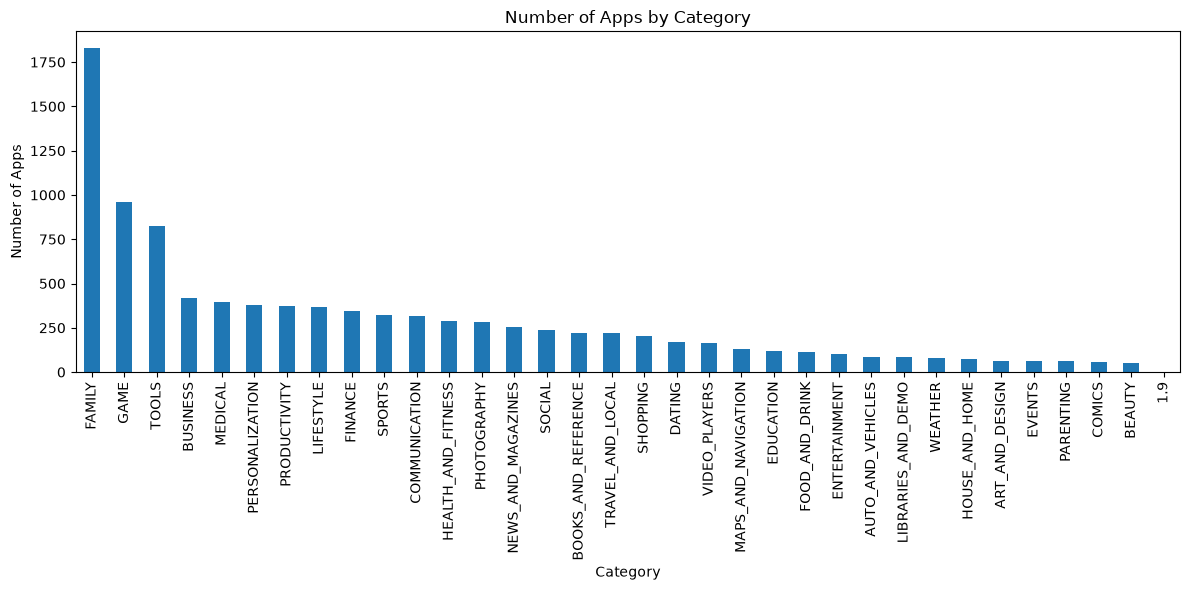

In [39]:
plt.figure(figsize=(12, 6))

category_counts.plot(kind='bar')

plt.title('Number of Apps by Category')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Observation

The distribution of apps across categories is uneven, indicating that some categories have considerably more applications than others. Categories with a high number of apps may represent highly competitive or saturated markets. Developers should consider competition levels alongside user demand before entering a category.

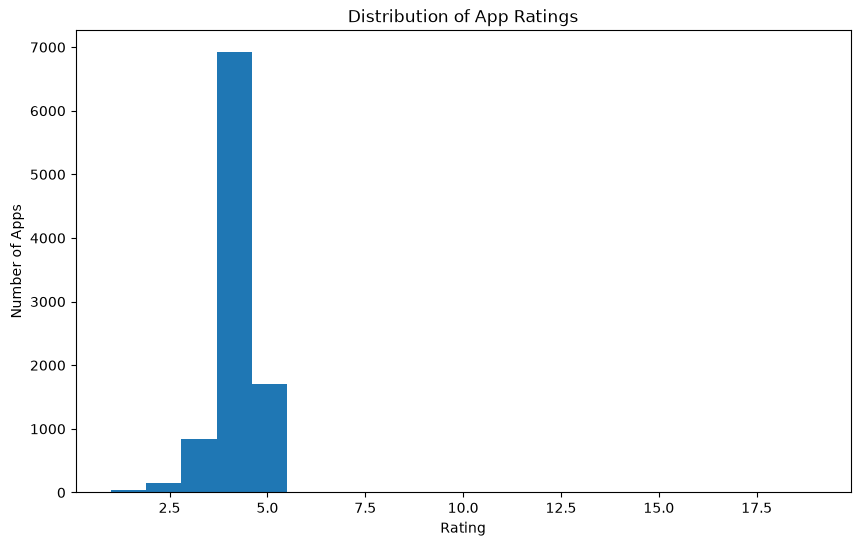

In [40]:
plt.figure(figsize=(10, 6))

plt.hist(apps_clean['Rating'].dropna(), bins=20)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')

plt.show()

### Observation

The rating distribution shows how user satisfaction varies across applications. Most apps are concentrated around the middle-to-high rating range, while relatively few apps receive extremely low ratings. This suggests that maintaining good user experience and app quality is important for achieving strong ratings.

In [41]:
avg_rating_category = (
    apps_clean.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)

avg_rating_category

Category
1.9                    19.000000
EVENTS                  4.454688
BOOKS_AND_REFERENCE     4.381982
EDUCATION               4.364706
ART_AND_DESIGN          4.359375
PERSONALIZATION         4.346277
PARENTING               4.316667
BEAUTY                  4.283019
HEALTH_AND_FITNESS      4.282292
SOCIAL                  4.255230
GAME                    4.249948
WEATHER                 4.248101
SHOPPING                4.237624
SPORTS                  4.232923
PRODUCTIVITY            4.206150
AUTO_AND_VEHICLES       4.205882
MEDICAL                 4.202025
FAMILY                  4.194378
FOOD_AND_DRINK          4.192857
COMICS                  4.189286
LIBRARIES_AND_DEMO      4.183333
PHOTOGRAPHY             4.166548
HOUSE_AND_HOME          4.158108
FINANCE                 4.138551
NEWS_AND_MAGAZINES      4.137008
BUSINESS                4.136429
COMMUNICATION           4.136190
ENTERTAINMENT           4.135294
LIFESTYLE               4.113008
TRAVEL_AND_LOCAL        4.088584
T

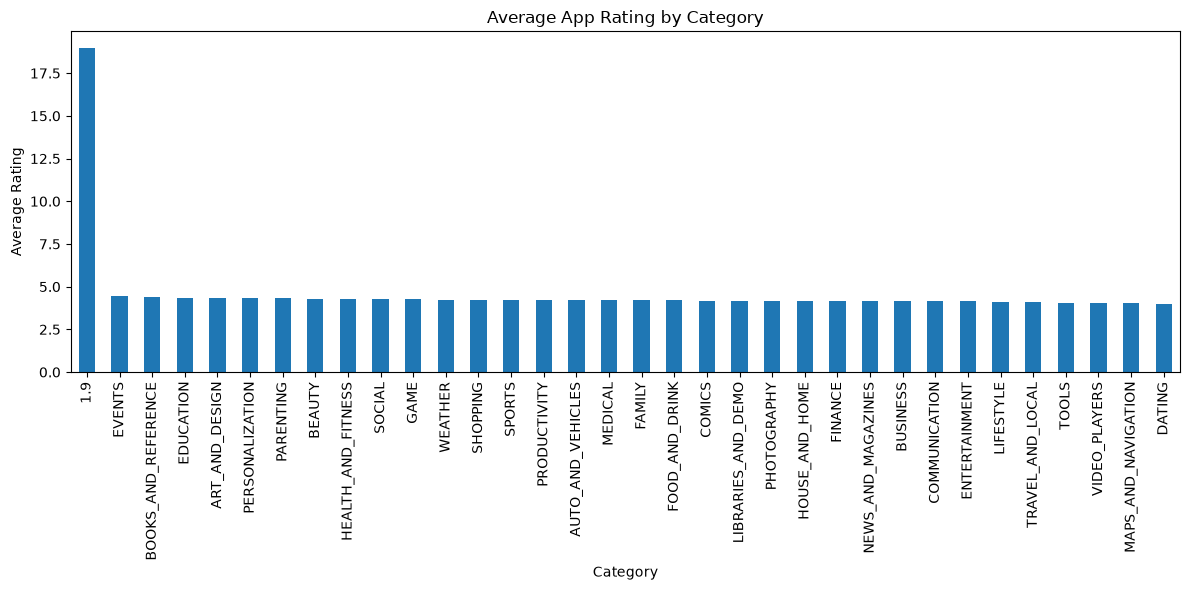

In [42]:
plt.figure(figsize=(12, 6))

avg_rating_category.plot(kind='bar')

plt.title('Average App Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

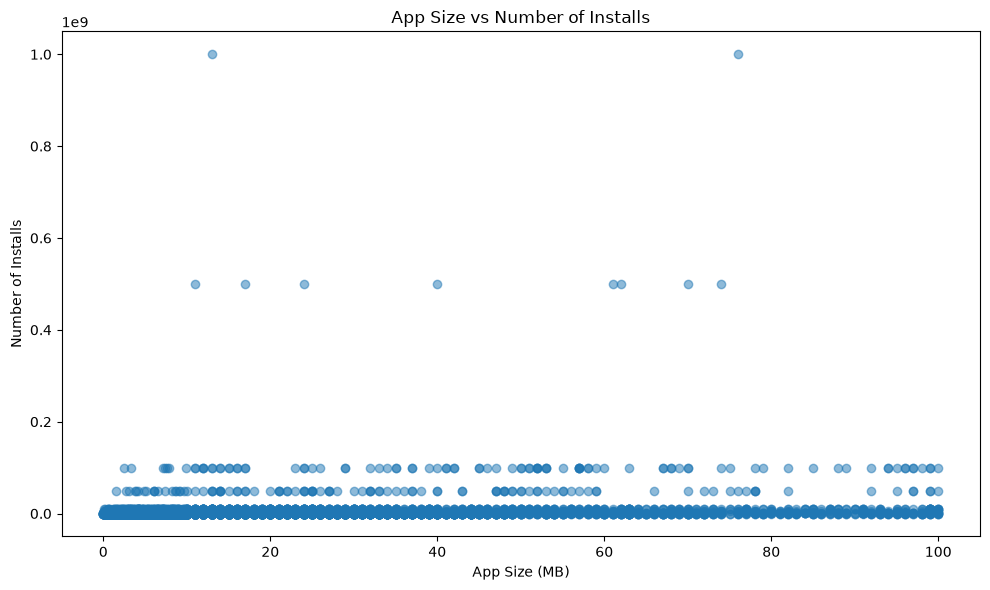

In [43]:
plt.figure(figsize=(10, 6))

plt.scatter(
    apps_clean['Size_MB'],
    apps_clean['Installs'],
    alpha=0.5
)

plt.title('App Size vs Number of Installs')
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Installs')

plt.tight_layout()
plt.show()

### Observation

The scatter plot helps examine whether larger applications tend to receive more or fewer installations. The distribution indicates the strength and direction of any relationship between app size and installs. However, app popularity is likely influenced by several other factors such as category, rating, reviews and app quality.

In [44]:
paid_apps = apps_clean[
    apps_clean['Type'] == 'Paid'
]

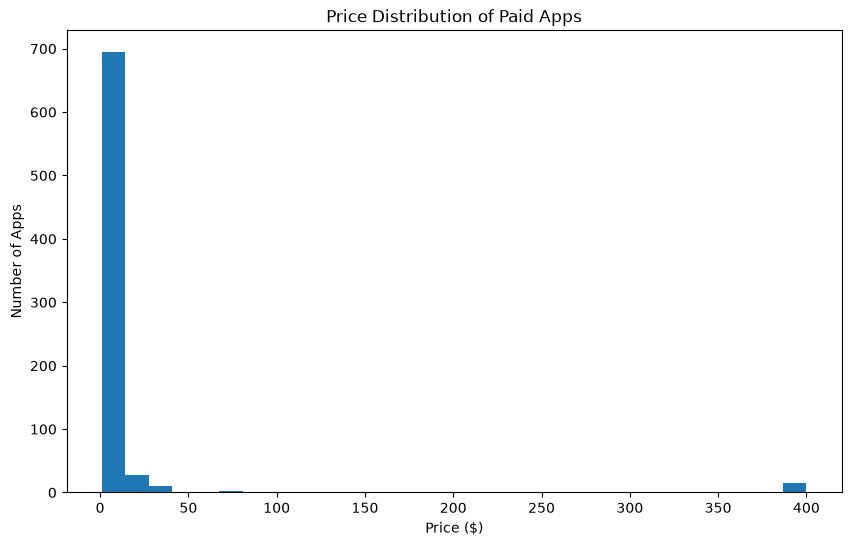

In [45]:
plt.figure(figsize=(10, 6))

plt.hist(paid_apps['Price'], bins=30)

plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')

plt.show()

In [46]:
apps_clean['Estimated_Revenue'] = np.where(
    apps_clean['Type'] == 'Paid',
    apps_clean['Price'] * apps_clean['Installs'],
    0
)

In [47]:
revenue_by_category = (
    apps_clean.groupby('Category')['Estimated_Revenue']
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category

Category
FAMILY                 1.136798e+08
LIFESTYLE              5.758394e+07
GAME                   4.068864e+07
FINANCE                2.572668e+07
PHOTOGRAPHY            8.547768e+06
PERSONALIZATION        6.796948e+06
MEDICAL                5.957536e+06
TOOLS                  5.464821e+06
SPORTS                 4.706212e+06
PRODUCTIVITY           4.313375e+06
COMMUNICATION          4.247364e+06
WEATHER                4.181380e+06
EDUCATION              2.403980e+06
HEALTH_AND_FITNESS     1.426069e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.151504e+06
BUSINESS               1.050543e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      1.001485e+05
BOOKS_AND_REFERENCE    9.022674e+04
DATING                 4.846150e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6.445000e+03
SOCIAL             

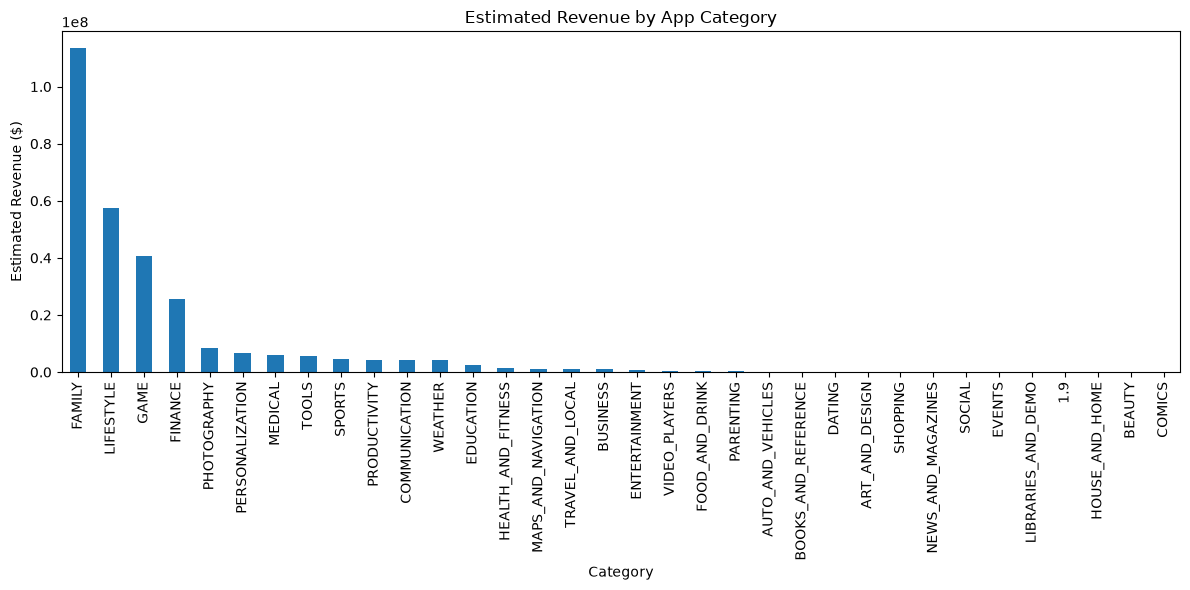

In [48]:
plt.figure(figsize=(12, 6))

revenue_by_category.plot(kind='bar')

plt.title('Estimated Revenue by App Category')
plt.xlabel('Category')
plt.ylabel('Estimated Revenue ($)')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Note on Revenue Estimation

Estimated revenue is calculated as Price × Installs for paid applications. This is only an approximation because the dataset does not provide actual purchase conversion rates, refunds, subscriptions or other monetization information.

In [49]:
reviews_clean.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [50]:
reviews_clean['Sentiment'].value_counts()

Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64

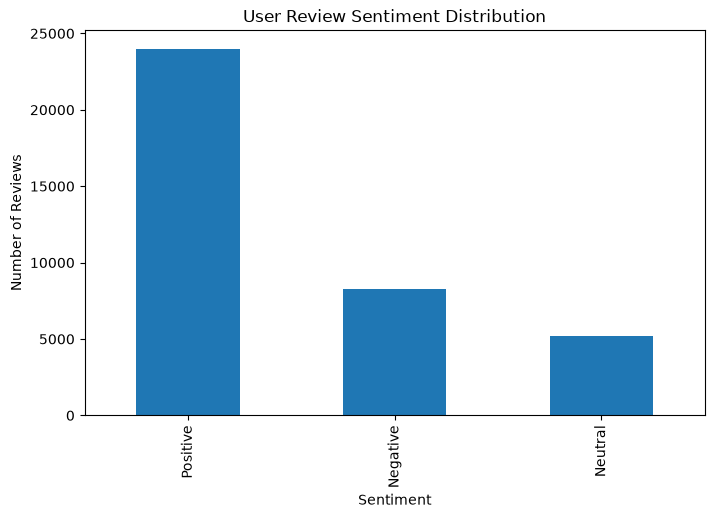

In [51]:
sentiment_counts = reviews_clean['Sentiment'].value_counts()

plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind='bar')

plt.title('User Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [52]:
app_category = apps_clean[['App', 'Category']].drop_duplicates()

In [53]:
reviews_category = reviews_clean.merge(
    app_category,
    on='App',
    how='left'
)

In [54]:
sentiment_category = pd.crosstab(
    reviews_category['Category'],
    reviews_category['Sentiment']
)

sentiment_category

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,61,62,259
AUTO_AND_VEHICLES,17,36,236
BEAUTY,65,88,185
BOOKS_AND_REFERENCE,95,108,448
BUSINESS,169,258,655
COMICS,1,6,39
COMMUNICATION,207,176,641
DATING,361,286,1068
EDUCATION,102,90,655


In [55]:
sentiment_percentage = pd.crosstab(
    reviews_category['Category'],
    reviews_category['Sentiment'],
    normalize='index'
) * 100

sentiment_percentage

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,15.968586,16.230366,67.801047
AUTO_AND_VEHICLES,5.882353,12.456747,81.660900
BEAUTY,19.230769,26.035503,54.733728
BOOKS_AND_REFERENCE,14.592934,16.589862,68.817204
BUSINESS,15.619224,23.844732,60.536044
COMICS,2.173913,13.043478,84.782609
COMMUNICATION,20.214844,17.187500,62.597656
DATING,21.049563,16.676385,62.274052
EDUCATION,12.042503,10.625738,77.331759


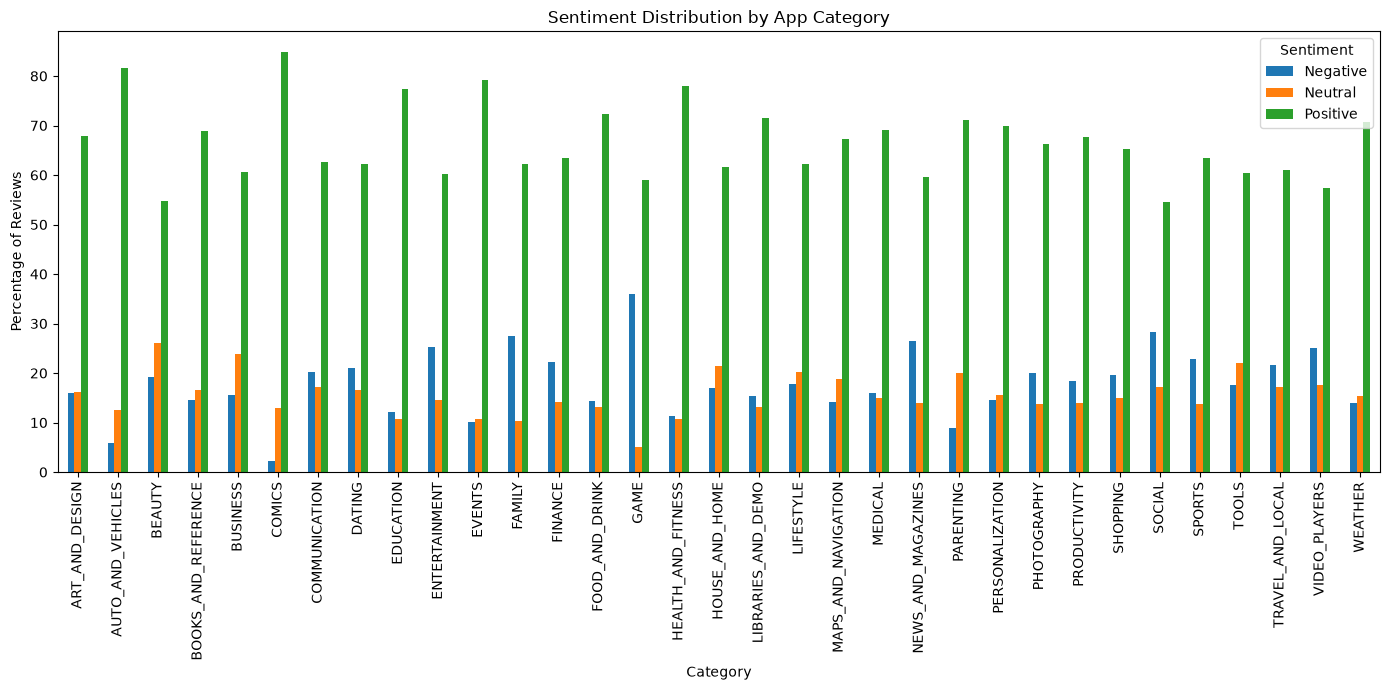

In [56]:
sentiment_percentage.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Sentiment Distribution by App Category')
plt.xlabel('Category')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [57]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
from wordcloud import WordCloud

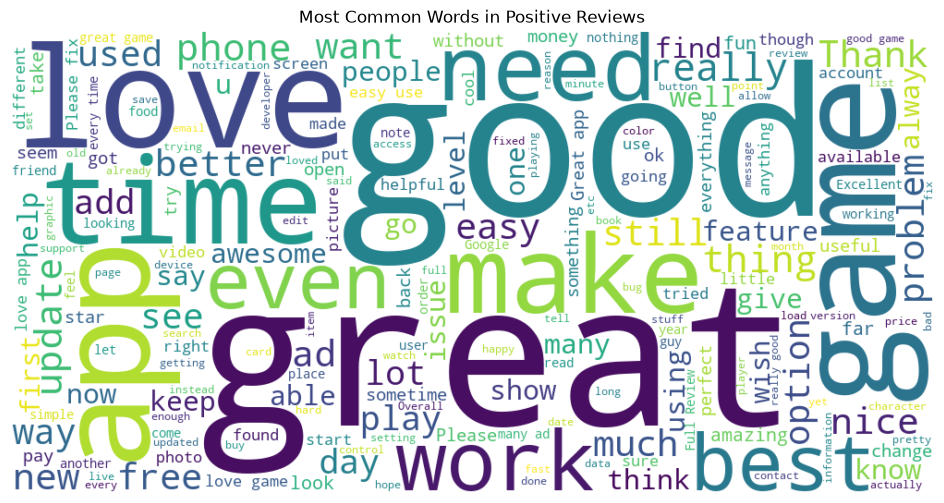

In [59]:
positive_text = ' '.join(
    reviews_clean[
        reviews_clean['Sentiment'] == 'Positive'
    ]['Translated_Review']
    .dropna()
)

wordcloud_positive = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews')
plt.show()

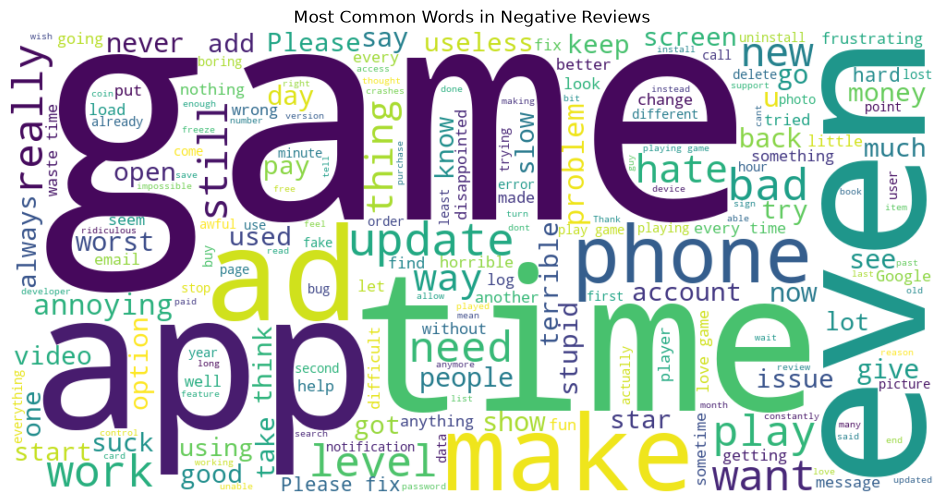

In [60]:
negative_text = ' '.join(
    reviews_clean[
        reviews_clean['Sentiment'] == 'Negative'
    ]['Translated_Review']
    .dropna()
)

wordcloud_negative = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews')
plt.show()

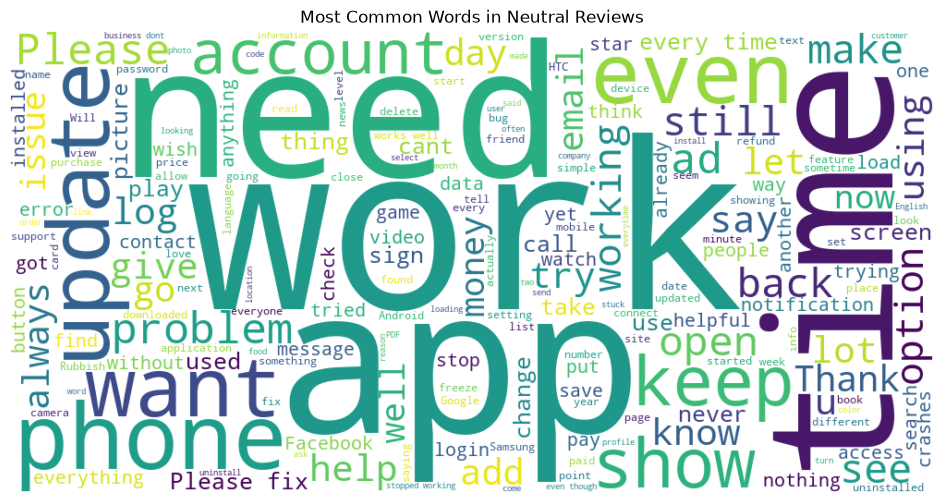

In [61]:
neutral_text = ' '.join(
    reviews_clean[
        reviews_clean['Sentiment'] == 'Neutral'
    ]['Translated_Review']
    .dropna()
)

wordcloud_neutral = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(neutral_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Neutral Reviews')
plt.show()

In [62]:
%pip install plotly

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.1 MB 1.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.1 MB 1.4 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.1 MB 1.3 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.1 MB 1.3 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.1 MB 1.3 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/9.1 MB 1.2 MB/s eta 0:00:07
   --------- ------------------------------ 2.1/9.1 MB 1.1 MB/s eta 0:00:07
   ---------- ----------------------------- 2.4/9.1 MB 1.1 MB/s eta 0:00:06
   ----------- ---------------------------- 2.6/9.1 MB 1.1 MB/s eta 0:00:06
   ------------ ------------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
import plotly.express as px

In [65]:
%pip install nbformat


   ----- ---------------------------------- 1/7 [fastjsonschema]
   ----- ---------------------------------- 1/7 [fastjsonschema]
   ----- ---------------------------------- 1/7 [fastjsonschema]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ---------------------- ----------------- 4/7 [jsonschema-specifications]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ----------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
fig.show()

NameError: name 'fig' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
apps = pd.read_csv("googleplaystore.csv")

In [4]:
category_counts = apps['Category'].value_counts()

In [5]:
fig = px.bar(
    x=category_counts.index,
    y=category_counts.values,
    title='Interactive App Category Distribution',
    labels={
        'x': 'Category',
        'y': 'Number of Apps'
    }
)

fig.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [8]:
apps = pd.read_csv("googleplaystore.csv")
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

In [9]:
apps_clean = apps.copy()
reviews_clean = reviews.copy()

In [10]:
apps_clean.shape

(10841, 13)

In [11]:
reviews_clean.shape

(64295, 5)

In [12]:
apps_clean['App'].duplicated().sum()

np.int64(1181)

In [13]:
apps_clean = apps_clean.drop_duplicates(subset='App', keep='first')

In [14]:
apps_clean.shape

(9660, 13)

In [15]:
# Remove the malformed record
apps_clean = apps_clean[apps_clean['Category'] != '1.9']

# Keep only valid ratings
apps_clean = apps_clean[
    apps_clean['Rating'].between(1, 5)
]

In [16]:
apps_clean.shape

(8196, 13)

In [17]:
apps_clean['Rating'].describe()

count    8196.000000
mean        4.173243
std         0.536625
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

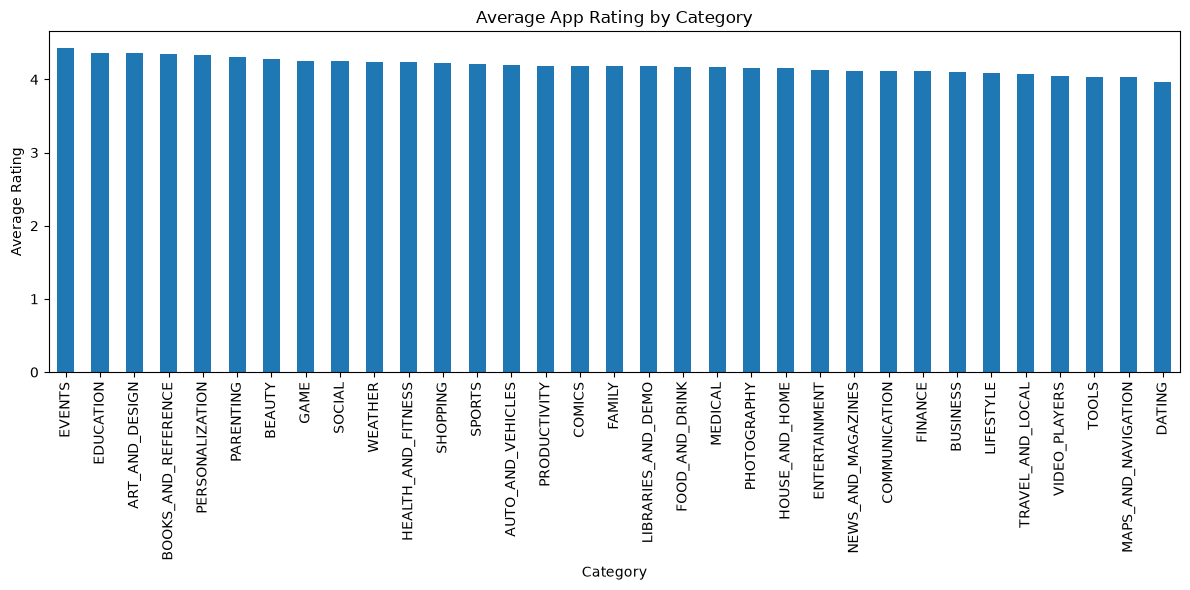

In [18]:
avg_rating_category = (
    apps_clean.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

avg_rating_category.plot(kind='bar')

plt.title('Average App Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Observation – App Ratings

- Average app ratings are generally high across all categories, ranging from approximately 4.0 to 4.4.
- Events has the highest average rating among the categories.
- Dating has one of the lowest average ratings.
- The relatively small difference between categories suggests that user ratings are consistently positive across the Google Play Store.

In [19]:
apps_clean.shape

(8196, 13)

In [20]:
apps_clean.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       4
Android Ver       2
dtype: int64

In [21]:
apps_clean['Current Ver'] = apps_clean['Current Ver'].fillna('Unknown')
apps_clean['Android Ver'] = apps_clean['Android Ver'].fillna('Unknown')

In [22]:
apps_clean.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [23]:
apps_clean.to_csv(
    'google_play_apps_cleaned.csv',
    index=False
)

# Final Conclusion

## Key Findings

- The FAMILY category contains the highest number of applications, followed by GAME and TOOLS.
- App ratings are generally high across categories, with average ratings mostly above 4.0.
- App size does not show a clear strong relationship with the number of installs, although several high-install applications appear as outliers.
- Most paid applications are concentrated in the lower price range, while a small number of expensive applications create significant price outliers.
- Positive reviews dominate across most application categories, indicating generally favorable user sentiment.
- Negative and neutral reviews provide useful insights into areas where application developers can improve user experience.

## Business Recommendations

1. Developers should evaluate category competition before launching new applications.
2. Maintaining app quality and user experience can help achieve higher ratings and positive reviews.
3. App size should be optimized where possible, but the analysis suggests that larger size alone does not guarantee more installs.
4. Developers should carefully evaluate pricing strategies for paid applications based on market demand and competition.
5. Negative user reviews should be monitored regularly to identify recurring problems and improve customer satisfaction.
6. Sentiment analysis can be used as an additional source of feedback when making product and feature decisions.